In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast
from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [2]:
import sys
# Ensure this analysis directory is importable regardless of kernel CWD
_here = '/projects/bhdw/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/analysis'
if _here not in sys.path:
    sys.path.insert(0, _here)

import dictys
from utils_custom import *
from pseudotime_curves import *
from episodic_dynamics import *
from config import *

In [3]:
import importlib
from firefate.utils import plots
importlib.reload(plots)
from episode_plots import *              # re-bind names into the notebook namespace

In [4]:
config = Config()

In [ ]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file('/work/nvme/bhdw/asachan/data_files/firefate/bcell/outs/dynamic.h5')

# Episodic enrichment plots

In [5]:
df_pb_ep1 = pd.read_csv(config.PB['ep1'])
df_pb_ep2 = pd.read_csv(config.PB['ep2'])
df_pb_ep3 = pd.read_csv(config.PB['ep3'])
df_pb_ep4 = pd.read_csv(config.PB['ep4'])

In [6]:
df_gc_ep1 = pd.read_csv(config.GC['ep1'])
df_gc_ep2 = pd.read_csv(config.GC['ep2'])
df_gc_ep3 = pd.read_csv(config.GC['ep3'])
df_gc_ep4 = pd.read_csv(config.GC['ep4'])

Filtered to 48 TFs that meet gene count criteria
Further filtered to 10 TFs that meet significance threshold < 0.003


/projects/bhdw/asachan/methods/FIREFate/src/firefate/utils/plots.py:464: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


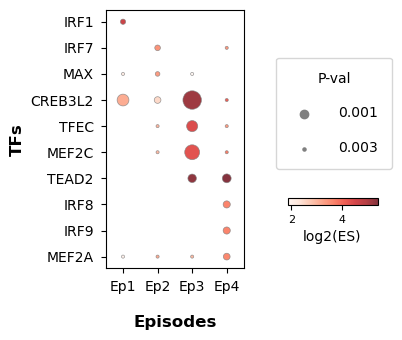

In [7]:
episode_labels=['Ep1', 'Ep2', 'Ep3', 'Ep4']

# Use it in the plot
fig, plot_data, plotted_tfs_pb = plots.plot_tf_episodic_enrichment_dotplot(
    dfs=[df_pb_ep1, df_pb_ep2, df_pb_ep3, df_pb_ep4],
    episode_labels=episode_labels,
    figsize=(4.5, 3.5), #breadth by length
    p_value_threshold=0.003,
    min_significance_threshold=0.003,
    min_dot_size=10,
    max_dot_size=200,
    cmap_name="Reds",
    tf_order=None,
    figure_title=None,
    log_scale=True,
    horizontal_layout=False
)
# save the plot
#fig.savefig(os.path.join("/projects/bhdw/asachan/papers/firefate/figures", "z11_pb_ee_003.pdf"), dpi=300)

Filtered to 48 TFs that meet gene count criteria
Further filtered to 7 TFs that meet significance threshold < 0.01


/projects/bhdw/asachan/methods/FIREFate/src/firefate/utils/plots.py:464: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


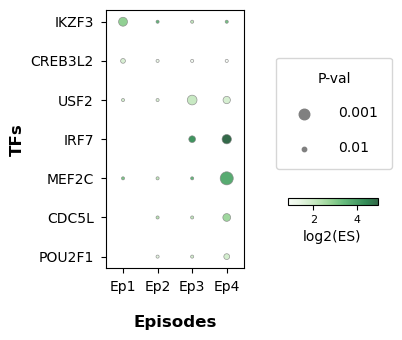

In [8]:
episode_labels=['Ep1', 'Ep2', 'Ep3', 'Ep4']

# Use it in the plot
fig, plot_data, plotted_tfs_gc = plot_tf_episodic_enrichment_dotplot(
    dfs=[df_gc_ep1, df_gc_ep2, df_gc_ep3, df_gc_ep4],
    episode_labels=episode_labels,
    figsize=(4.5, 3.5), #breadth by length
    p_value_threshold=0.01,
    min_significance_threshold=0.01,
    min_dot_size=10,    
    max_dot_size=200,   
    cmap_name="Greens",
    tf_order=None,
    figure_title=None,
    log_scale=True,
    horizontal_layout=False
)
# save the plot
#fig.savefig(os.path.join("/projects/bhdw/asachan/papers/firefate/figures", "z11_gc_ee_01.pdf"), dpi=300)

## Episodic links

In [9]:
# For each enriched (plotted) TF, list its LF target genes (genes_in_lf) ONLY in the
# episodes where it actually passed the enrichment threshold in the dotplot.
# Per-episode threshold matches the dotplot calls above: PB=0.003 (cell 8), GC=0.01 (cell 9).
# A dot is "enriched" when p_value <= p_value_threshold; otherwise it is shrunk to min_dot_size*0.5.
# TF order follows the dotplot (peak episode first, then decreasing peak ES), not the alphabet.
PB_PVAL_THRESHOLD = 0.003
GC_PVAL_THRESHOLD = 0.01

def parse_genes_in_lf(genes_str):
    try:
        if pd.isna(genes_str) or genes_str in ('', '()'):
            return ()
        val = ast.literal_eval(genes_str)
        return val if isinstance(val, tuple) else (val,)
    except Exception:
        return ()

def collect_lf_targets(dfs_by_episode, enriched_tfs, lineage, p_value_threshold):
    # enriched_tfs is the dotplot's own TF order (its 3rd return value): TFs peaking in
    # Ep1 first, then Ep2, ..., and within a block by decreasing peak ES.
    tf_rank = {tf: i for i, tf in enumerate(enriched_tfs)}
    rows = []
    for episode, df in dfs_by_episode.items():
        sub = df[(df['TF'].isin(tf_rank.keys())) & (df['p_value'] <= p_value_threshold)]
        for _, r in sub.iterrows():
            genes = parse_genes_in_lf(r['genes_in_lf'])
            if not genes:                      # enriched episode but no LF target genes -> no link
                continue
            rows.append({
                'lineage': lineage,
                'episode': episode,
                'TF': r['TF'],
                'tf_rank': tf_rank[r['TF']],
                'enrichment_score': r['enrichment_score'],
                'p_value': r['p_value'],
                'genes_in_lf': ', '.join(genes),
                'n_genes_in_lf': len(genes),
            })
    return rows

pb_dfs = {'Ep1': df_pb_ep1, 'Ep2': df_pb_ep2, 'Ep3': df_pb_ep3, 'Ep4': df_pb_ep4}
gc_dfs = {'Ep1': df_gc_ep1, 'Ep2': df_gc_ep2, 'Ep3': df_gc_ep3, 'Ep4': df_gc_ep4}

enriched_tf_lf_targets = (
    pd.DataFrame(
        collect_lf_targets(pb_dfs, plotted_tfs_pb, 'PB', PB_PVAL_THRESHOLD)
        + collect_lf_targets(gc_dfs, plotted_tfs_gc, 'GC', GC_PVAL_THRESHOLD)
    )
    .sort_values(['lineage', 'tf_rank', 'episode'])
    .drop(columns='tf_rank')
    .reset_index(drop=True)
)

display(enriched_tf_lf_targets)

out_path = os.path.join(config.OUTPUT_FOLDER, "enriched_tf_lf_targets_per_episode.csv")
#enriched_tf_lf_targets.to_csv(out_path, index=False)
print(f"Saved {len(enriched_tf_lf_targets)} rows to {out_path}")

,lineage,episode,TF,enrichment_score,p_value,genes_in_lf,n_genes_in_lf
0,GC,Ep1,IKZF3,7.152924,0.002195,"ANKRD28, CD74, PIKFYVE, RNF213",4
1,GC,Ep1,CREB3L2,3.275286,0.009150,"FNDC3A, HSP90B1, LMAN1, SSR1, TRAM1, TXNDC5",6
2,GC,Ep3,USF2,4.020163,0.001520,"FNDC3A, HSP90B1, LMAN1, RNF213, SSR1, SUB1, TRAM1",7
3,GC,Ep4,USF2,3.366430,0.004210,"FNDC3A, HSP90B1, LMAN1, RNF213, SSR1, SUB1, TRAM1",7
4,GC,Ep3,IRF7,18.112821,0.005185,"B2M, CEP128",2
5,GC,Ep4,IRF7,30.297872,0.001808,"B2M, CEP128",2
6,GC,Ep4,MEF2C,13.101783,0.000220,"IRF4, SEL1L3, SLA, TNFAIP8",4
7,GC,Ep4,CDC5L,6.295662,0.003546,"ARNTL2, MZB1, TNFAIP8, UBAC2",4
8,GC,Ep4,POU2F1,3.479182,0.006940,"CCSER2, DEK, EEA1, IRF4, MAPK1, SLC25A13",6
9,PB,Ep1,IRF1,25.812865,0.002501,"RNF213, UBAC2",2


Saved 22 rows to /projects/bhdw/asachan/papers/firefate/figures/enriched_tf_lf_targets_per_episode.csv


### Bar plots of ES and target split between states

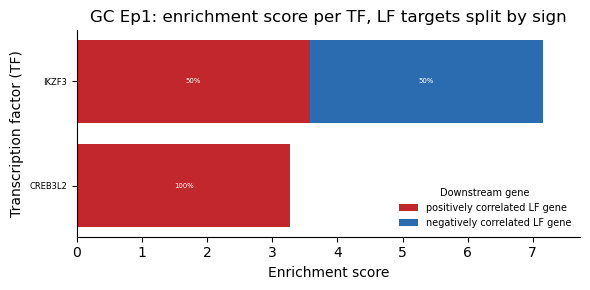

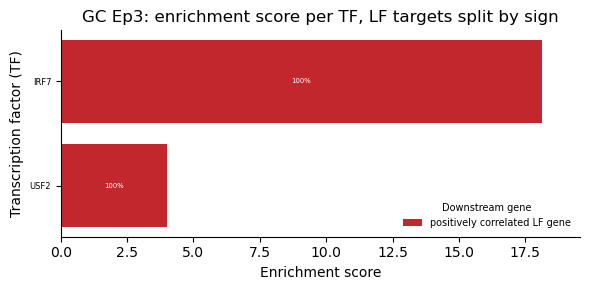

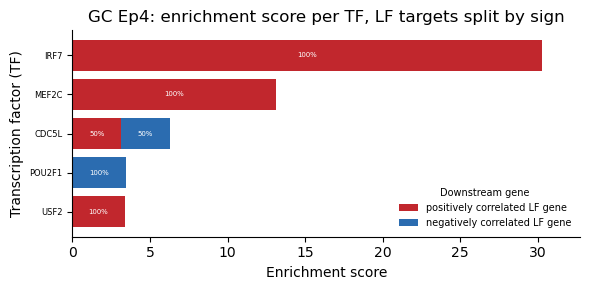

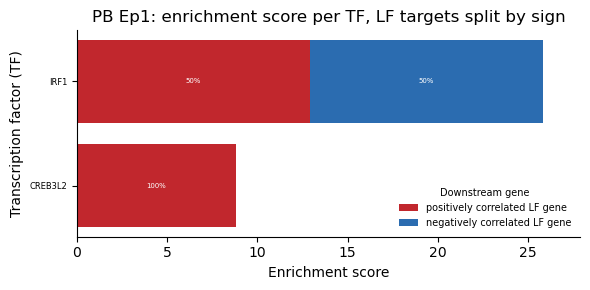

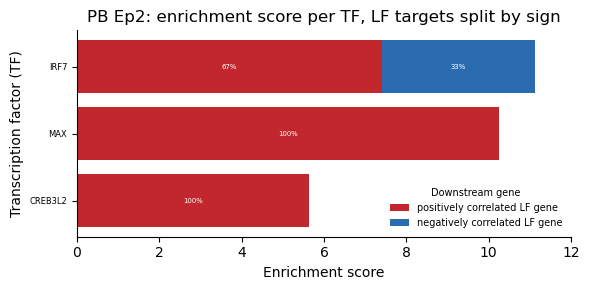

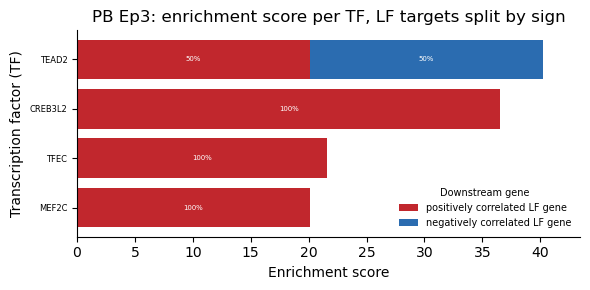

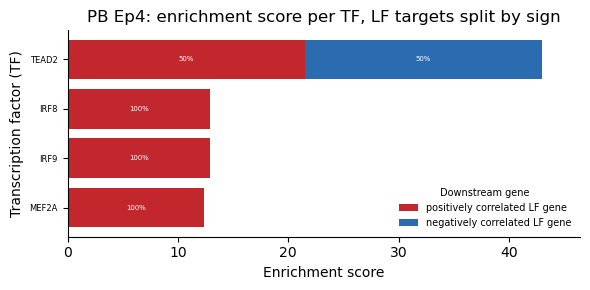

In [10]:
from firefate.enrichment import build_tf_color_bar_table, load_lf_gene_colors

# Red = positively correlated Z11 gene, blue = negatively correlated.
LF_FEATURE_FILES = ['/work/nvme/bhdw/asachan/data_files/firefate/bcell/latent_factors/feature_list_Z11_GC_PB.txt']
gene_colors = load_lf_gene_colors(LF_FEATURE_FILES)

def es_bar_plot(sub, lineage, episode):
    """Bar height = enrichment score; stack = that TF's LF targets split by LF sign."""
    links = pd.DataFrame(
        [{'source': r['TF'], 'target': g}
         for _, r in sub.iterrows()
         for g in r['genes_in_lf'].split(', ')
         if g in gene_colors],                      # LF genes only -> no gray segment
        columns=['source', 'target'],
    ).drop_duplicates()
    if links.empty:
        print(f"{lineage} {episode}: no LF targets, skipped")
        return None
    plot_df = build_tf_color_bar_table(
        links,
        sub[['TF', 'enrichment_score']].rename(columns={'enrichment_score': 'score'}),
        gene_colors,
    )
    fig, _ = plots.plot_tf_enrichment_bars(
        plot_df,
        f"{lineage} {episode}: enrichment score per TF, LF targets split by sign",
        out_path=os.path.join(config.OUTPUT_FOLDER, f"z11_{lineage.lower()}_es_bars_{episode.lower()}.pdf"),
    )
    return plot_df

es_bar_tables = {
    (lineage, episode): es_bar_plot(sub, lineage, episode)
    for (lineage, episode), sub in enriched_tf_lf_targets.groupby(['lineage', 'episode'])
}

# Shape of TF expression curves for each of the enriched TFs

In [ ]:
branches = {'PlasmaBlast': (0, 2), 'GerminalCenter': (0, 3)}

def classify_branch(branch_to_plot, tf_list, mode="expression"):
    """Wave-pattern classification of TF expression shape for one branch."""
    rng = branches[branch_to_plot]
    sc = SmoothedCurvesGRN(dictys_dynamic_object, trajectory_range=rng,
        num_points=100, dist=0.0005, sparsity=0.01, mode=mode)
    dy, dx = sc.get_smoothed_curves()
    df = sc.classify_wave_patterns(dx.values, dy, tf_list=tf_list)
    df["branch"] = branch_to_plot
    return df

In [ ]:
state_specific_tfs_pb = ['CREB3L2', 'XBP1', 'PRDM1', 'IRF4', 'RUNX2', 'HERPUD1', 'HIVEP2', 'ARID5B', 'TFEC', 'TCF12', 'AFF1']

In [ ]:
episodic_tfs_pb = ['CREB3L2', 'IRF1', 'IRF7', 'IRF9', 'IRF8', 'MAX', 'MEF2A', 'TFEC', 'TEAD2']

In [ ]:
expression_shape_df_pb = classify_branch('PlasmaBlast', episodic_tfs_pb, mode="expression")
expression_shape_df_pb[["branch", "trajectory", "wave_pattern"]]

In [ ]:
expression_shape_df_gc = classify_branch('GerminalCenter', plotted_tfs_gc)
expression_shape_df_gc[["branch", "trajectory", "wave_pattern"]]